# EUROPEAN CALL OPTION WITH HESTON VOLATILITY MODEL

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import scipy

The stochastic model for stock price and volatility

$$ dS = (r-q)Sdt + \sqrt{v}S dW_1$$

$$ dv = \kappa(\theta - v)dt + \xi \sqrt{v}dW_2$$

$$ \mathbb{E}[dW_1 dW_2] = \rho dt$$

The above gives rise to the following PDE:

$$ \partial_t U  + \frac{1}{2}vS^2 \partial^2_S U + (r-q)S \partial_S U - rU + \rho \xi v S \partial_S \partial_v U + \frac{1}{2}\xi^2 v \partial^2_v U + \kappa(\theta - v)\partial_v U = 0$$

Making the transformation $\tau = T - t$ and $x = ln(S/K)$ we get

$$ \partial_\tau U = \frac{1}{2}v(\partial^2_x U - \partial_x U) + (r-q)\partial_x U - rU + \rho \xi v \partial_x \partial_v U + \frac{1}{2}\xi^2 v \partial^2_v U + \kappa(\theta - v)\partial_v U $$

Conditions:

$$ U(\tau = 0, S, v) = max(S-K,0) = max(Ke^x - K, 0)$$

$$ U(\tau, -w, v) = 0 $$

$$ U(\tau, w, v) = Ke^w e^{-q \tau} - Ke^{-r \tau}$$

$$ \partial_v U(\tau, x, v_{max})  = 0$$


In [2]:
#risk free rate
r = 0.03

#dividends
q = 0.01

#parameters for volatility 

kappa = 2.

theta = 0.04

xi = 0.3

rho = -0.7


#strike price
K = 100.

#time to maturity
T = 1.

#width of transformed S coordinate
w = 2.

#highest volatility
vmax = 1.

In [3]:
#range of S's covered

K*np.exp(-w), K*np.exp(w)

(13.53352832366127, 738.905609893065)

## Load in Chebyshev polynomials and match to initial data

In [4]:
n1 = 50
n2 = 25
n = max(n1,n2)

diff1 = np.loadtxt('../diffmatrix100.txt')[0:n1,0:n1]
diff2 = np.loadtxt('../diffmatrix100.txt')[0:n2,0:n2]

chebyshevs = []
for i in range(0, n):
    chebyshevs.append(scipy.special.chebyt(i))

In [5]:
# tau array

tau = np.linspace(0, T, int(T/10**-3 + 1))
dtau = tau[1:] - tau[0:-1]

# solution array

c = np.zeros((len(tau), 2*(n1*n2)))

In [6]:
def calc_T_matrix(dim, xcol):
    T = np.zeros(dim)
    for i in range(0,dim):
        T[i] = chebyshevs[i](xcol)
    return T

#All Gauss-Lobatto Nodes
xcol = np.cos(np.pi*np.linspace(0, n1-1, n1)/(n1-1))
vcol = np.cos(np.pi*np.linspace(0, n2-1, n2)/(n2-1))

#collocation matrices
Txcol = np.zeros((len(xcol),n1))
Tvcol = np.zeros((len(vcol),n2))

for i in range(0, len(xcol)):
    Txcol[i,:] = calc_T_matrix(n1, xcol[i])

for i in range(0, len(vcol)):
    Tvcol[i,:] = calc_T_matrix(n2, vcol[i])

#this does exactly what it is supposed to do!
Txvcol = np.kron(Tvcol, Txcol)
    

In [7]:
# transform from numerical coordinates to physical coordinates

def xnum_to_xleft(xnum):
    return (xnum - 1.)*(w/2) 

def xnum_to_xright(xnum):
    return (xnum + 1.)*(w/2)

def xnum_to_v(xnum):
    return (xnum + 1.)*(vmax/2.)

In [8]:
def get_coeff(f, xnum_to_x): #xnum_to_x depends on which side; we know the left side will be irrelevant but oh well

    x = xnum_to_x(xcol)
    #v = xnum_to_v(vcol) #this is not actually consequential since initial data does not depend on volatility

    L = Txvcol
    R = np.tile(f(x), n2) 
    
    c = np.linalg.solve(L, R)
    return c

In [9]:
# match to initial data using 2 cells.

#data does not depend on volatility at termination/tau = 0

#first cell

fID_left = lambda x: np.zeros(len(x))

c[0,0:n1*n2] = get_coeff(fID_left, xnum_to_xleft)

#second cell

fID_right = lambda x: K*(np.exp(x) - 1.)

c[0,n1*n2:] = get_coeff(fID_right, xnum_to_xright)

In [10]:
# functions to plot data



xplot = np.linspace(-1,1,101)
vplot = np.linspace(-1,1,101)

#plot matrix
Txplot = np.zeros((len(xplot),n1))
Tvplot = np.zeros((len(vplot),n2))

for i in range(0, len(xplot)):
    Txplot[i,:] = calc_T_matrix(n1, xplot[i])
    Tvplot[i,:] = calc_T_matrix(n2, vplot[i])


# plot data fox fixed volatility and time

def plot_fixed_tau_v(tau_index, v_index):

    left_sol = np.reshape(c[tau_index, 0:n1*n2], (n2,n1)).T
    right_sol = np.reshape(c[tau_index, n1*n2:], (n2,n1)).T

    left_vals = Txplot@left_sol@Tvplot[v_index,:]
    
    right_vals = Txplot@right_sol@Tvplot[v_index,:]

    #left part
  
    plt.plot(xnum_to_xleft(xplot), left_vals, c='blue')
       
    #right part
   
    plt.plot(xnum_to_xright(xplot), right_vals, c='blue')
       
    plt.axvline(x = 0, c='black', linewidth=1)

    v = xnum_to_v(vplot[v_index])
   
    plt.title('U(x,v) at '+r'$\tau=$ '+str(tau[tau_index])+r' $v=$'+str(v))
    plt.ylabel(r'$U$')
    plt.xlabel(r'$x$')
    plt.show()


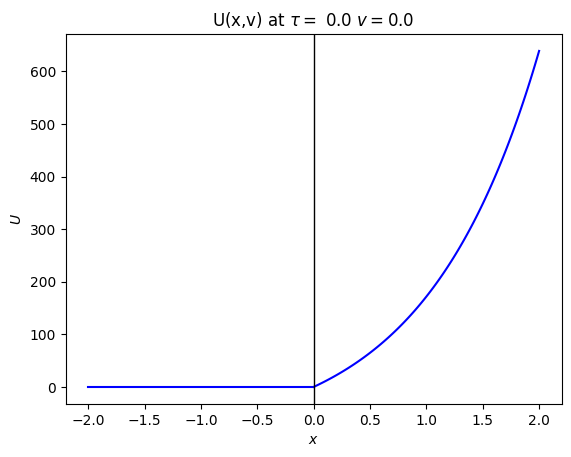

In [11]:
plot_fixed_tau_v(0, 0)

## Transform PDE to Numerical Coordinates

\begin{equation}
\begin{aligned}
 \partial_\tau U & = \frac{1}{2}v((2/w)^2\partial^2_{xnum} U - (2/w)\partial_{xnum} U) + (r-q)(2/w)\partial_{xnum} U - rU + \rho \xi v (2/w)(2/vmax)\partial_{xnum} \partial_{vnum} U \\
 & + \frac{1}{2}\xi^2 v (2/vmax)^2\partial^2_{vum} U + \kappa(\theta - v)(2/vmax)\partial_{vnum} U 
 
 \end{aligned}
 \end{equation}

## Assemble Matrices for Time Evolution

In [12]:


#collocation matrices
Txinnercol = np.zeros((len(xcol)-2,n1))
Tvinnercol = np.zeros((len(vcol)-1,n2))

Txinnercol = np.array([calc_T_matrix(n1, x) for x in xcol[1:-1]])
Tvinnercol = np.array([calc_T_matrix(n2, v) for v in vcol[1:]])

Txinnercol_diff = Txinnercol @ diff1
Txinnercol_diff2 = Txinnercol_diff @ diff1

Tvinnercol_diff = Tvinnercol @ diff2
Tvinnercol_diff2 = Tvinnercol_diff @ diff2

v_vals = np.repeat(xnum_to_v(vcol[1:]), n1-2)[:, None]

Lhomo = np.kron(Tvinnercol, Txinnercol)

R1homo = ( 0.5*((2/w)**2*np.kron(Tvinnercol, Txinnercol_diff2)
           - (2/w)*np.kron(Tvinnercol, Txinnercol_diff))
    + rho*xi*(2/w)*(2/vmax)*np.kron(Tvinnercol_diff, Txinnercol_diff)
    + 0.5*xi**2*(2/vmax)**2*np.kron(Tvinnercol_diff2, Txinnercol)
    - kappa*(2/vmax)*np.kron(Tvinnercol_diff, Txinnercol) )

R2homo = ( (r-q)*(2/w)*np.kron(Tvinnercol, Txinnercol_diff)
    - r*np.kron(Tvinnercol, Txinnercol)
    + kappa*theta*(2/vmax)*np.kron(Tvinnercol_diff, Txinnercol) )

Rhomo = v_vals*R1homo + R2homo


In [13]:

#prepare the matrices. We abuse the fact that only one boundary condition depends on tau(time).

L = np.zeros((2*(n1*n2), 2*(n1*n2)))
R = np.zeros((2*(n1*n2), 2*(n1*n2)))

###################################################################################################

#left outermost

L[0:(n1-2)*(n2-1), 0:n1*n2] = Lhomo
R[0:(n1-2)*(n2-1), 0:n1*n2] = Rhomo

row_count = (n1 - 2)*(n2 - 1)    

#####################################################################################################################################


#right outermost cell

L[row_count:row_count + (n1-2)*(n2-1), n1*n2:] = Lhomo
R[row_count:row_count + (n1-2)*(n2-1), n1*n2:] = Rhomo

row_count = row_count + (n1 - 2)*(n2 - 1)

#############################################################################################################################################

#boundary conditions in x; impose each n2 times

#x=-w
R[row_count:row_count + n2, 0:n1*n2] = np.kron(Tvcol ,calc_T_matrix(n1, -1.))

row_count = row_count + n2

#x=+w
jump_index_start = row_count
R[row_count:row_count + n2, n1*n2:] = np.kron(Tvcol ,calc_T_matrix(n1, +1.))

row_count = row_count + n2

#x=0, continuity
R[row_count:row_count + n2, 0:n1*n2] = -1*np.kron(Tvcol ,calc_T_matrix(n1, +1.))
R[row_count: row_count + n2, n1*n2:] = 1*np.kron(Tvcol ,calc_T_matrix(n1, -1.))
    
row_count = row_count + n2

#x=0, differentiability
R[row_count:row_count + n2, 0:n1*n2] = -(2/w)*np.kron(Tvcol ,calc_T_matrix(n1, +1.)@diff1)
R[row_count:row_count + n2, n1*n2: ] = +(2/w)*np.kron(Tvcol ,calc_T_matrix(n1, -1.)@diff1)

row_count = row_count + n2

#boundary conditions at v = vmax; impose over inner x points only
R[row_count:row_count + n1-2, 0:n1*n2] = (2/vmax)*np.kron(calc_T_matrix(n2,+1.)@diff2, Txinnercol)

row_count = row_count + n1 - 2

R[row_count:row_count + n1-2, n1*n2:] = (2/vmax)*np.kron(calc_T_matrix(n2,+1.)@diff2, Txinnercol)

row_count = row_count + n1-2

print(jump_index_start, row_count)

2329 2500


## Time Evolution

In [14]:
a11 = 4.772644573858262e-01
c1 = a11

a21 = -1.970525884150017e-01
a22 = 4.763634284595835e-01
c2 = a21 + a22

a31 = -3.476744303729656e-02
a32 = 6.330518073354831e-01
a33 = 1.936343100750279e-01
c3 = a31 + a32 + a33

a41 = 9.677976685787021e-02
a42 = -1.935335264665350e-01
a43 = -2.076229458004729e-04
a44 = 1.595722048494314e-01
c4 = a41 + a42 + a43 + a44

a51 = 1.625272318198749e-01
a52 = -2.496725135473825e-01
a53 = -4.590799720417948e-02
a54 = 3.657947640085904e-01
a55 = 2.557528383076989e-01
c5 = a51 + a52 + a53 + a54 + a55

a61 = -7.076031971712624e-03
a62 = 8.462998548602952e-01
a63 = 3.440200169250181e-01
a64 = -7.209260545488652e-02
a65 = -2.154923319808753e-01
a66 = 1.043410976221611e-01
c6 = a61 + a62 + a63 + a64 + a65 + a66


a71 = 1.768579351797444e-03
a72 = 7.799600131275149e-02
a73 = 3.033332775645574e-01
a74 = 2.131608067328356e-01
a75 = 3.517693203190381e-01
a76 = -3.815458943865381e-01
a77 = 4.335179091055582e-01
c7 = a71 + a72 + a73 + a74 + a75 + a76 + a77

a81 = 0.000000000000000e+00
a82 = 2.273235341055902e-01
a83 = 3.084158379801177e-01
a84 = 1.572634195730069e-01
a85 = 2.435511371522748e-01
a86 = -1.209536267328315e-01
a87 = -8.026784733998993e-02
a88 =  2.646675452618318e-01
c8 = a81 + a82 + a83 + a84 + a85 + a86 + a87 + a88

b1 = a81
b2 = a82
b3 = a83
b4 = a84
b5 = a85
b6 = a86
b7 = a87
b8 = a88

In [15]:
Lbar1inv = np.linalg.inv(L - R*(dtau[0])*(a11))
Lbar2inv = np.linalg.inv(L - R*(dtau[0])*(a22))
Lbar3inv = np.linalg.inv(L - R*(dtau[0])*(a33))
Lbar4inv = np.linalg.inv(L - R*(dtau[0])*(a44))
Lbar5inv = np.linalg.inv(L - R*(dtau[0])*(a55))
Lbar6inv = np.linalg.inv(L - R*(dtau[0])*(a66))
Lbar7inv = np.linalg.inv(L - R*(dtau[0])*(a77))
Lbar8inv = np.linalg.inv(L - R*(dtau[0])*(a88))

In [16]:
def calc_K(c, tau_inp, dtau_inp, K1, K2, K3, K4, K5, K6, K7, key):

    dtau = dtau_inp

    if key == 1:
        tau = tau_inp + dtau*c1
    elif key == 2:
        tau = tau_inp + dtau*c2
    elif key == 3:
        tau = tau_inp + dtau*c3
    elif key == 4:
        tau = tau_inp + dtau*c4
    elif key == 5:
        tau = tau_inp + dtau*c5
    elif key == 6:
        tau = tau_inp + dtau*c6
    elif key == 7:
        tau = tau_inp + dtau*c7
    elif key == 8:
        tau = tau_inp + dtau*c8

    J = np.zeros(2*(n1*n2))
    J[jump_index_start:jump_index_start+n2] = K*(np.exp(w - q*tau) - np.exp(-r*tau))

#################################################################################################################################################

    if key == 1:
        Rbar = np.matmul(R, c) - J
        K1 = Lbar1inv@Rbar
        return K1
    elif key == 2:
        Rbar = np.matmul(R, c + dtau*K1*a21) - J
        K2 = Lbar2inv@Rbar
        return K2
    elif key == 3:
        Rbar = np.matmul(R, c + dtau*K1*a31 + dtau*K2*a32) - J
        K3 = Lbar3inv@Rbar
        return K3
    elif key == 4:
        Rbar = np.matmul(R, c + dtau*K1*a41 + dtau*K2*a42 + dtau*K3*a43) - J
        K4 = Lbar4inv@Rbar
        return K4
    elif key == 5:
        Rbar = np.matmul(R, c + dtau*K1*a51 + dtau*K2*a52 + dtau*K3*a53 + dtau*K4*a54) - J
        K5 = Lbar5inv@Rbar
        return K5
    elif key == 6:
        Rbar = np.matmul(R, c + dtau*K1*a61 + dtau*K2*a62 + dtau*K3*a63 + dtau*K4*a64 + dtau*K5*a65) - J
        K6 = Lbar6inv@Rbar
        return K6
    elif key == 7:
        Rbar = np.matmul(R, c + dtau*K1*a71 + dtau*K2*a72 + dtau*K3*a73 + dtau*K4*a74 + dtau*K5*a75 + dtau*K6*a76) - J
        K7 = Lbar7inv@Rbar
        return K7
    elif key == 8:
        Rbar = np.matmul(R, c + dtau*K1*a81 + dtau*K2*a82 + dtau*K3*a83 + dtau*K4*a84 + dtau*K5*a85 + dtau*K6*a86 + dtau*K7*a87) - J
        K8 = Lbar8inv@Rbar
        return K8

    

In [17]:
#Calculate Data for all Times

for i in range(0, len(tau)-1):
    K1 = calc_K(c[i,:],tau[i], dtau[i], None, None, None, None, None, None, None, 1)
    K2 = calc_K(c[i,:],tau[i], dtau[i], K1, None, None, None, None, None, None, 2)
    K3 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, None, None, None, None, None, 3)
    K4 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, None, None, None, None, 4)
    K5 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , None, None, None, 5)
    K6 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, None, None, 6)
    K7 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, None, 7)
    K8 = calc_K(c[i,:],tau[i], dtau[i], K1, K2, K3, K4 , K5, K6, K7, 8)

    c[i+1,:] = c[i,:] + dtau[i]*(b1*K1 + b2*K2 +b3*K3 + b4*K4 + b5*K5 + b6*K6 + b7*K7 + b8*K8)
    
    if i%100==0:
        print(i)
        print('The time is: '+str(tau[i]))
        print('The average of the Chebychev coefficients is: '+str(np.mean(np.abs(c[i,:]))))

0
The time is: 0.0
The average of the Chebychev coefficients is: 0.2555622439572261
100
The time is: 0.1
The average of the Chebychev coefficients is: 0.2651294747662909
200
The time is: 0.2
The average of the Chebychev coefficients is: 0.26785600764731204
300
The time is: 0.3
The average of the Chebychev coefficients is: 0.2695247750307463
400
The time is: 0.4
The average of the Chebychev coefficients is: 0.270552949221779
500
The time is: 0.5
The average of the Chebychev coefficients is: 0.271251679638397
600
The time is: 0.6
The average of the Chebychev coefficients is: 0.27168114621237477
700
The time is: 0.7000000000000001
The average of the Chebychev coefficients is: 0.2719216545980159
800
The time is: 0.8
The average of the Chebychev coefficients is: 0.27207509354636394
900
The time is: 0.9
The average of the Chebychev coefficients is: 0.2721333136445294


## Analysis

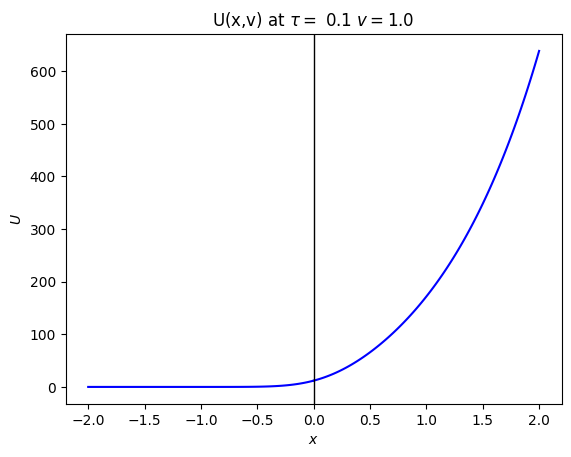

In [18]:
plot_fixed_tau_v(100, 100)

Checked Fourier integral with Claude

## Make heatmap movie

In [19]:
def build_heatmap_data(c):
    
    data = np.zeros((len(tau), len(vplot), 2*len(xplot)))

    for i in range(0, len(tau)):
    
        left_sol = np.reshape(c[i, 0:n1*n2], (n2,n1)).T
        right_sol = np.reshape(c[i, n1*n2:], (n2,n1)).T
    
        left_vals = Txplot@left_sol@Tvplot.T
        
        right_vals = Txplot@right_sol@Tvplot.T

        data[i,:,0:len(xplot)] = left_vals.T
        data[i,:,len(xplot):] = right_vals.T  
       
    return data

In [20]:
heatmap_data = build_heatmap_data(c)

In [21]:
# physical axes
x_phys = np.concatenate([xnum_to_xleft(xplot), xnum_to_xright(xplot)])   # (202,)
v_phys = xnum_to_v(vplot)                                               # (101,)
S_phys = K*np.exp(x_phys)

X, V = np.meshgrid(x_phys, v_phys)



In [30]:
eps  = 1e-12
dlog = np.log10(np.abs(heatmap_data) + eps)     # also kills the divide-by-zero
lo, hi = -6.0, dlog.max()   

In [33]:
def plot_frame(index, ax):

    maturity = ax[0]
    instant = ax[1]

    pc = maturity.pcolormesh(X, V, dlog[0], shading='auto', cmap='viridis', vmin = lo, vmax=hi)
    cb1 = plt.colorbar(pc, label =r'$\log_{10}|\text{Call Price}|$')                
    maturity.set_xlabel(r'$x=\ln(\text{Stock}/\text{Strike})$', fontsize=20); maturity.set_ylabel('Volatility(v)', fontsize=20)
    maturity.set_title(r'$\text{Call Price}(x,v)$ at '+ rf'$t={T-tau[0]:.3f}$', fontsize=20)

    pc = instant.pcolormesh(X, V, dlog[index], shading='auto', cmap='viridis', vmin=lo, vmax=hi)
    cb2 = plt.colorbar(pc)               
    #instant.set_xlabel(r'$x=\ln(\text{Stock}/\text{Strike})$', fontsize=20); instant.set_ylabel('Volatility(v)', fontsize=20)
    instant.set_title(r'$\text{Call Price}(x,v)$ at '+ rf'$t={T-tau[index]:.3f}$', fontsize=20)

    return cb1, cb2
    


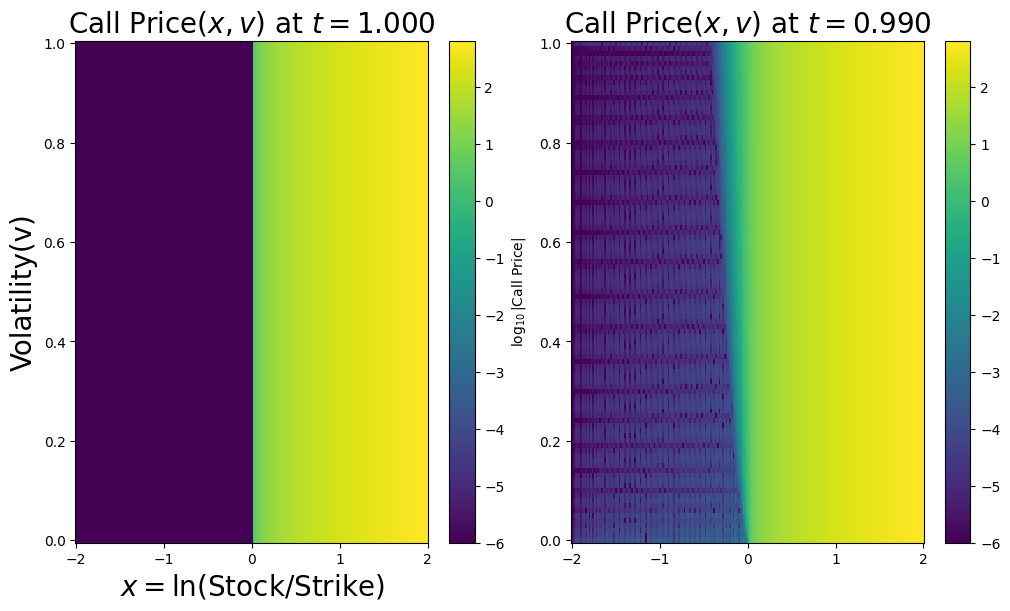

In [34]:
fig, ax = plt.subplots(1,2, figsize=(10, 6), constrained_layout=True)
plot_frame(10,ax)
plt.show()

In [35]:
from matplotlib.animation import PillowWriter

In [36]:
metadata = dict(title='Movie', artist ='ayush_roy')
writer = PillowWriter(fps=10, metadata = metadata)

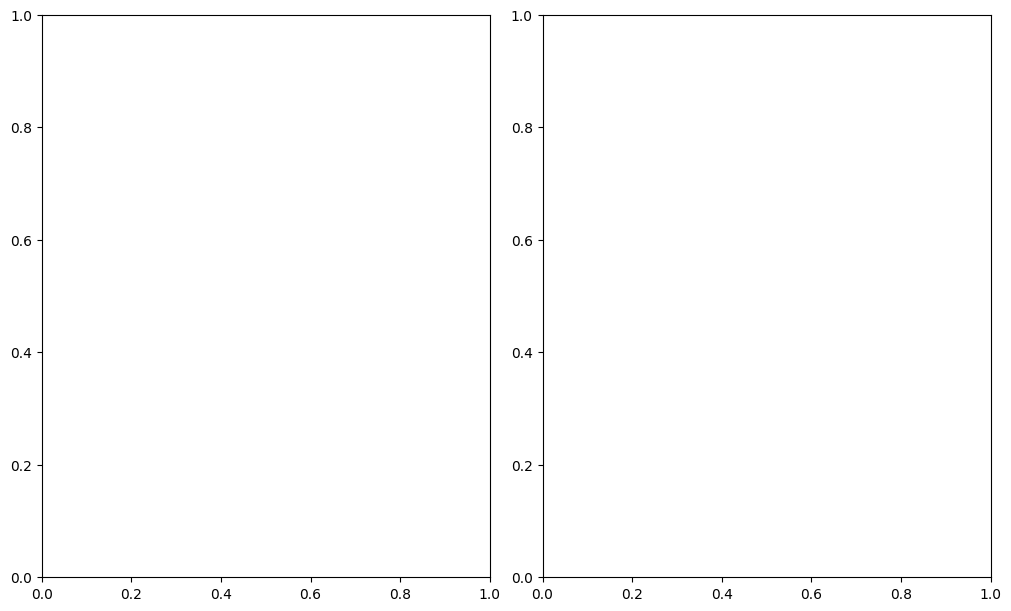

In [37]:
fig, ax = plt.subplots(1,2, figsize=(10, 6), constrained_layout=True)

with writer.saving(fig, 'heston_pde.gif',100):
    for i in range(0, len(tau)):
        if i%4 == 0:
            cb1, cb2 = plot_frame(i, ax)
            writer.grab_frame()
            cb1.remove(); cb2.remove()
            ax[0].clear()
            ax[1].clear()
            
       